# 可审计可视化输出 v2（按论文提纲 4.1–4.4）

目标：
- 对齐提纲第 4 章输出：T/I/M、分层表、反例库、过程证据链
- 保持现有 notebook 风格：自动存图 + 存表 + 输出清单
- 不依赖 legacy 脚本

默认输出目录：`paper_figures_v2/`

In [1]:
from pathlib import Path
from datetime import datetime
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name.lower() == 'tools':
    BASE_DIR = BASE_DIR.parent

ANALYSIS_DIR = BASE_DIR / 'analysis_results'
OUTPUT_DIR = BASE_DIR / 'paper_figures_v2'
CATEGORIES = {
    'transparency': OUTPUT_DIR / '1_transparency',
    'efficiency': OUTPUT_DIR / '2_efficiency',
    'reliability': OUTPUT_DIR / '3_reliability',
    'sensitivity': OUTPUT_DIR / '4_sensitivity',
    'tables': OUTPUT_DIR / '5_tables',
    'diagnostics': OUTPUT_DIR / '6_diagnostics',
}
for p in CATEGORIES.values():
    p.mkdir(parents=True, exist_ok=True)

def find_latest_quality_report(root: Path) -> Path:
    cands = list(root.glob('quality_report_*.csv')) + list(root.glob('**/quality_report_*.csv'))
    cands = [p for p in cands if p.is_file()]
    if not cands:
        raise FileNotFoundError(f'未找到 quality_report CSV: {root}')
    cands.sort(key=lambda x: x.stat().st_mtime, reverse=True)
    return cands[0]

def save_figure(fig, stem: str, category: str, dpi: int = 220):
    out = CATEGORIES[category] / f'{stem}.pdf'
    fig.savefig(out, dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f'💾 [saved] {out}')
    plt.close(fig)

def save_table(df: pd.DataFrame, stem: str, category: str = 'tables', index: bool = False):
    out = CATEGORIES[category] / f'{stem}.csv'
    df.to_csv(out, index=index, encoding='utf-8-sig')
    print(f'💾 [saved] {out}')

def parse_choices(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return []
    if isinstance(v, list):
        return [str(x).strip() for x in v if str(x).strip()]
    s = str(v).strip()
    if not s:
        return []
    if s.startswith('[') and s.endswith(']'):
        try:
            obj = ast.literal_eval(s)
            if isinstance(obj, list):
                return [str(x).strip() for x in obj if str(x).strip()]
        except Exception:
            pass
    if ';' in s:
        return [x.strip() for x in s.split(';') if x.strip()]
    return [s]

CSV_PATH = find_latest_quality_report(ANALYSIS_DIR)
print('Using CSV:', CSV_PATH)
print('Output dir:', OUTPUT_DIR)

Using CSV: D:\Work\HOHONET\analysis_results\quality_report_20260126.csv
Output dir: D:\Work\HOHONET\paper_figures_v2


In [2]:
# Section 1: Data Cleaning & Definitions (沿用原版口径)
# 目标：尽量复用你已验证过的清洗逻辑与口径命名，减少迁移风险。

def clean_str_col(df: pd.DataFrame, col: str) -> None:
    if col not in df.columns:
        return
    s = df[col]
    s = s.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA, "none": pd.NA})
    df[col] = s


def to_bool_tristate(v):
    if pd.isna(v):
        return pd.NA
    if isinstance(v, bool):
        return v
    s = str(v).strip().lower()
    if s in {"true", "1", "yes", "y"}:
        return True
    if s in {"false", "0", "no", "n"}:
        return False
    return pd.NA


SCOPE_OOS_PREFIXES = ("oos", "out-of-scope", "out of scope")
SCOPE_NORMAL_VALUES = ("normal", "in-scope", "camera room", "只标相机房间")


def normalize_condition(s: str) -> str:
    if pd.isna(s):
        return "unknown"
    ss = str(s).strip().lower()
    if "semi" in ss:
        return "semi"
    if "manual" in ss:
        return "manual"
    return ss if ss else "unknown"


def is_oos_scope(s) -> bool:
    if pd.isna(s):
        return False
    ss = str(s).strip().lower()
    return any(ss.startswith(prefix) for prefix in SCOPE_OOS_PREFIXES)


def is_normal_scope(s) -> bool:
    if pd.isna(s):
        return False
    ss = str(s).strip().lower()
    return ss == "normal" or any(v in ss for v in SCOPE_NORMAL_VALUES)


def clean_quality_df(df_raw: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    """
    清洗与口径定义（与原 notebook 保持一致的关键字段）：
    - scope_clean / scope_missing / is_oos_clean / is_normal_clean
    - layout_used_clean / reliability_used_clean
    - data_valid_inscope / data_valid_for_main / data_valid_for_reliability
    """
    df = df_raw.copy()

    # 1) 字符串列标准化
    for col in ["scope", "condition", "layout_gate_reason", "difficulty", "model_issue"]:
        if col in df.columns:
            clean_str_col(df, col)

    # 2) 语义识别（保持原版命名）
    df["scope_clean"] = df["scope"] if "scope" in df.columns else pd.NA
    df["scope_missing"] = df["scope_clean"].isna()
    df["is_oos_clean"] = df["scope_clean"].apply(is_oos_scope)
    df["is_normal_clean"] = df["scope_clean"].apply(is_normal_scope)

    if "condition" in df.columns:
        df["condition_clean"] = df["condition"].apply(normalize_condition)
    else:
        df["condition_clean"] = "unknown"

    # 3) 布尔字段三态清洗
    for col in ["layout_used", "pointwise_rmse_used", "reliability_used"]:
        if col in df.columns:
            df[f"{col}_clean"] = df[col].apply(to_bool_tristate)

    # 4) 兼容：若没有 *_clean，则给默认值
    if "layout_used_clean" not in df.columns:
        df["layout_used_clean"] = True
    if "reliability_used_clean" not in df.columns:
        if "iou_to_consensus_loo" in df.columns:
            df["reliability_used_clean"] = df["iou_to_consensus_loo"].notna()
        elif "iou_to_others_median" in df.columns:
            df["reliability_used_clean"] = df["iou_to_others_median"].notna()
        else:
            df["reliability_used_clean"] = False

    # 5) 口径掩码（沿用原版核心逻辑）
    df["data_valid_inscope"] = df["is_normal_clean"] & (~df["scope_missing"])

    # Main: in-scope + condition可识别（不强耦合 layout_used）
    df["data_valid_for_main"] = (
        df["data_valid_inscope"]
        & df["condition_clean"].isin(["manual", "semi"])
    )

    # Reliability: 在 Main 基础上，再要求 reliability_used
    df["data_valid_for_reliability"] = (
        df["data_valid_for_main"]
        & (df["reliability_used_clean"] == True)
    )

    # 6) 标签解析（供分层表直接使用）
    if "difficulty" in df.columns:
        df["tag_difficulty"] = df["difficulty"].apply(parse_choices)
    else:
        df["tag_difficulty"] = [[] for _ in range(len(df))]

    if "model_issue" in df.columns:
        df["tag_model_issue"] = df["model_issue"].apply(parse_choices)
    else:
        df["tag_model_issue"] = [[] for _ in range(len(df))]

    if verbose:
        print("✅ clean_quality_df done")
        print(f"   Total rows: {len(df)}")
        print(f"   In-scope subset: {int(df['data_valid_inscope'].sum())}")
        print(f"   Main (Perf) subset: {int(df['data_valid_for_main'].sum())}")
        print(f"   Reliability subset: {int(df['data_valid_for_reliability'].sum())}")
        if "reliability_used_clean" in df.columns:
            print("   reliability_used_clean=True:", int((df["reliability_used_clean"] == True).sum()))

    return df


raw = pd.read_csv(CSV_PATH)
for c in ["active_time", "iou", "iou_to_consensus_loo", "iou_to_others_median", "boundary_rmse_px", "delta_n_pairs", "pred_n_pairs", "ann_n_pairs"]:
    if c in raw.columns:
        raw[c] = pd.to_numeric(raw[c], errors="coerce")

df_clean = clean_quality_df(raw, verbose=True)

# 口径别名（与原版一致 + 兼容本 v2 后续单元）
df_transparent = df_clean
df_inscope = df_clean[df_clean["data_valid_inscope"]].copy()
df_main = df_clean[df_clean["data_valid_for_main"]].copy()
df_rel = df_clean[df_clean["data_valid_for_reliability"]].copy()

# 兼容后续变量名
df = df_clean
df_I = df_inscope
df_M = df_main

# reliability 主列
tmp_rel_col = "iou_to_consensus_loo" if "iou_to_consensus_loo" in df.columns else ("iou_to_others_median" if "iou_to_others_median" in df.columns else None)
reli_col = tmp_rel_col
print("reliability column:", reli_col)

df.head(2)

rows: 174 | tasks: 29
reliability column: iou_to_consensus_loo


,dataset_group,project_version,task_id,title,image_url,condition,annotator_id,active_time,iou,iou_manual,...,task_scope_majority,task_scope_is_mixed,task_scope_has_unknown,analysis_role,is_oos_v2,is_inscope_v2,layout_used_v2,scope_missing_v2,tag_difficulty,tag_model_issue
0,Manual_Test,v1.0,459,b8cTxDM8gDG_f63819c407e64c2897b703080766cb60.png,http://106.53.106.49:8000/data/mp3d_layout/tes...,semi,2,188.282,1.0,1.0,...,unknown,False,True,performance,NaN,False,False,True,[],[]
1,Manual_Test,v1.0,461,rPc6DW4iMge_7316bf706e0d46368334c0c989210e09.png,http://106.53.106.49:8000/data/mp3d_layout/tes...,semi,2,7.509,1.0,1.0,...,unknown,False,True,performance,NaN,False,False,True,[],[]


## Section 0.5 数据概览与字段检查

本节目的：
- 先确认 CSV 字段类型、缺失率与关键布尔门控分布；
- 明确 `T / I / M` 三层口径的输入字段是否齐全；
- 在后续绘图前，提前暴露字段异常（避免“画出来才发现口径错了”）。

关键字段（与原版一致）：
- 语义口径：`scope_clean`, `scope_missing`, `is_oos_clean`, `is_normal_clean`, `condition_clean`
- 主分析门控：`data_valid_inscope`, `data_valid_for_main`, `data_valid_for_reliability`
- 可靠性字段：`iou_to_consensus_loo`（优先）或 `iou_to_others_median`
- layout 门控：`layout_used_clean`, `layout_gate_reason`

In [ ]:
print('📋 字段概览:')
print('n_rows=', len(df), 'n_cols=', len(df.columns))
print('columns(sample)=', list(df.columns[:20]))

print('\n📋 关键字段分布:')
for col in ["condition_clean", "scope_clean", "layout_used_clean", "reliability_used_clean", "data_valid_inscope", "data_valid_for_main", "data_valid_for_reliability"]:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts(dropna=False).head(10))

field_specs = [
    ("Scope", "scope_clean", "任务范围原始语义字段（清洗后）"),
    ("ScopeMissing", "scope_missing", "scope 是否缺失"),
    ("IsOOS", "is_oos_clean", "是否 OOS"),
    ("IsInScope", "is_normal_clean", "是否 In-scope"),
    ("Condition", "condition_clean", "manual / semi 条件"),
    ("LayoutUsed", "layout_used_clean", "标准 layout 指标是否可用"),
    ("LayoutGateReason", "layout_gate_reason", "layout 不可用原因"),
    ("ReliabilityUsed", "reliability_used_clean", "可靠性口径是否可用"),
    ("MainMask", "data_valid_for_main", "主分析掩码"),
    ("ReliabilityMask", "data_valid_for_reliability", "可靠性分析掩码"),
    ("IoU", "iou", "主 IoU 指标"),
    ("LOO", "iou_to_consensus_loo", "LOO 共识一致性"),
    ("OthersMedian", "iou_to_others_median", "与他人中位一致性"),
    ("BoundaryRMSE", "boundary_rmse_px", "边界误差"),
    ("ActiveTime", "active_time", "活跃标注时间"),
    ("DeltaPairs", "delta_n_pairs", "角点对数差"),
]

rows = []
for display_name, col, meaning in field_specs:
    if col in df.columns:
        s = df[col]
        miss = int(s.isna().sum())
        total = len(df)
        miss_rate = miss / total if total else np.nan
        rows.append({
            "字段": display_name,
            "列名": col,
            "含义": meaning,
            "总数": total,
            "缺失数": miss,
            "缺失率": miss_rate,
            "示例值": str(s.dropna().iloc[0]) if s.dropna().shape[0] else "(all missing)",
        })

field_table = pd.DataFrame(rows)
display(field_table)
save_table(field_table, "Table_P0_field_dictionary", category="tables", index=False)

## 4.1 三级口径 T / I / M

In [3]:
n_T = len(df)
df_I = df[df['is_inscope_v2'] == True].copy()
n_I = len(df_I)
df_M = df_I[df_I['layout_used_v2'] == True].copy()
n_M = len(df_M)

rows = [
    {'tier': 'T_total', 'n_rows': n_T, 'coverage_vs_T': 1.0},
    {'tier': 'I_in_scope', 'n_rows': n_I, 'coverage_vs_T': (n_I / n_T if n_T else np.nan)},
    {'tier': 'M_model_usable', 'n_rows': n_M, 'coverage_vs_T': (n_M / n_T if n_T else np.nan)},
]

if 'layout_gate_reason' in df.columns:
    vc = df_I.loc[~df_I['layout_used_v2'], 'layout_gate_reason'].fillna('unknown').value_counts()
    for reason, cnt in vc.items():
        rows.append({'tier': f'gate_fail::{reason}', 'n_rows': int(cnt), 'coverage_vs_T': cnt / n_T if n_T else np.nan})

rows.append({'tier': 'scope_missing', 'n_rows': int(df['scope_missing_v2'].sum()), 'coverage_vs_T': float(df['scope_missing_v2'].mean())})
for col in ['annotator_id', 'task_id', 'script_version']:
    if col in df.columns:
        miss = df[col].isna() | (df[col].astype(str).str.strip() == '') | (df[col].astype(str).str.lower() == 'unknown')
        rows.append({'tier': f'{col}_unknown_or_missing', 'n_rows': int(miss.sum()), 'coverage_vs_T': float(miss.mean())})

table_p0 = pd.DataFrame(rows)
display(table_p0)
save_table(table_p0, 'Table_P0_field_audit')

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.bar(['T', 'I', 'M'], [n_T, n_I, n_M], color=['#4C72B0', '#55A868', '#C44E52'])
ax.set_title('Fig.P0 T/I/M Coverage Funnel')
ax.set_ylabel('Rows')
for i, v in enumerate([n_T, n_I, n_M]):
    ax.text(i, v, str(v), ha='center', va='bottom')
save_figure(fig, 'Fig_P0_tier_funnel', 'transparency')

,tier,n_rows,coverage_vs_T
0,T_total,174,1.000000
1,I_in_scope,122,0.701149
2,M_model_usable,120,0.689655
3,gate_fail::low_coverage,2,0.011494
4,scope_missing,28,0.160920
5,annotator_id_unknown_or_missing,0,0.000000
6,task_id_unknown_or_missing,0,0.000000


💾 [saved] D:\Work\HOHONET\paper_figures_v2\5_tables\Table_P0_field_audit.csv
💾 [saved] D:\Work\HOHONET\paper_figures_v2\1_transparency\Fig_P0_tier_funnel.pdf


In [5]:
cond_col = 'condition_clean' if 'condition_clean' in df_I.columns else ('condition' if 'condition' in df_I.columns else None)
if 'active_time' in df_I.columns and cond_col:
    fig, ax = plt.subplots(figsize=(6.8, 4.4))
    sns.boxplot(data=df_I, x=cond_col, y='active_time', ax=ax, showfliers=False)
    sns.stripplot(data=df_I, x=cond_col, y='active_time', ax=ax, color='black', alpha=0.25, size=2.3)
    ax.set_title('Fig.P1 Efficiency: Active Time by Condition (In-scope)')
    ax.set_xlabel('Condition')
    ax.set_ylabel('Active Time (sec)')
    save_figure(fig, 'Fig_P1_efficiency_active_time', 'efficiency')
else:
    print('skip Fig_P1: missing active_time or condition-like column')

💾 [saved] D:\Work\HOHONET\paper_figures_v2\2_efficiency\Fig_P1_efficiency_active_time.pdf


## 4.2 分层表 A / B1 / B2 / C + 工人四象限

In [10]:
# 兼容：若 CSV 没有 delta_n_pairs，则尝试由 pred/ann 角点对数推导
if 'delta_n_pairs' not in df.columns:
    pred_col = 'pred_n_pairs' if 'pred_n_pairs' in df.columns else ('n_pairs_pred' if 'n_pairs_pred' in df.columns else None)
    ann_col = 'ann_n_pairs' if 'ann_n_pairs' in df.columns else ('n_pairs_ann' if 'n_pairs_ann' in df.columns else None)
    if pred_col and ann_col:
        df['delta_n_pairs'] = pd.to_numeric(df[ann_col], errors='coerce') - pd.to_numeric(df[pred_col], errors='coerce')
        df_I['delta_n_pairs'] = pd.to_numeric(df_I.get(ann_col), errors='coerce') - pd.to_numeric(df_I.get(pred_col), errors='coerce')
        df_M['delta_n_pairs'] = pd.to_numeric(df_M.get(ann_col), errors='coerce') - pd.to_numeric(df_M.get(pred_col), errors='coerce')
        print('delta_n_pairs derived from', ann_col, '-', pred_col)
    else:
        print('delta_n_pairs unavailable: no source pair-count columns found')

delta_n_pairs derived from ann_n_pairs - pred_n_pairs


In [11]:
if 'delta_n_pairs' in df_M.columns:
    bins = [-1e9, -2, -1, 0, 1, 2, 1e9]
    labels = ['<=-2', '-1', '0', '1', '2', '>=3']
    tmp = df_M.copy()
    tmp['delta_bin'] = pd.cut(tmp['delta_n_pairs'], bins=bins, labels=labels)
    metrics = [m for m in ['iou', 'boundary_rmse_px', 'active_time'] if m in tmp.columns]
    agg = tmp.groupby('delta_bin', dropna=False).agg(
        n_rows=('task_id', 'count'),
        **{f'median_{m}': (m, 'median') for m in metrics}
    ).reset_index()
    display(agg)
    save_table(agg, 'Table_A_delta_n_pairs')
else:
    print('skip Table_A_delta_n_pairs: missing delta_n_pairs')

def build_tag_table(df_src: pd.DataFrame, list_col: str, out_name: str):
    rows = []
    for _, r in df_src.iterrows():
        tags = r[list_col] if isinstance(r[list_col], list) else []
        for t in tags:
            rows.append({
                'tag': t,
                'active_time': r['active_time'] if 'active_time' in df_src.columns else np.nan,
                'iou': r['iou'] if 'iou' in df_src.columns else np.nan,
                'reliability': r[reli_col] if reli_col and reli_col in df_src.columns else np.nan,
            })
    if not rows:
        print(f'skip {out_name}: empty tags')
        return None
    tdf = pd.DataFrame(rows)
    out = tdf.groupby('tag').agg(
        n=('tag', 'count'),
        median_active_time=('active_time', 'median'),
        median_iou=('iou', 'median'),
        median_reliability=('reliability', 'median'),
    ).sort_values('n', ascending=False).reset_index()
    save_table(out, out_name)
    display(out.head(20))
    return out

table_b1 = build_tag_table(df_I, 'tag_difficulty', 'Table_B1_difficulty')
table_b2 = build_tag_table(df_I, 'tag_model_issue', 'Table_B2_model_issue')

if 'task_id' in df.columns:
    scope_by_task = df.groupby('task_id')['is_oos_v2'].agg(lambda s: s.dropna().unique().tolist()).reset_index(name='scope_votes')
    scope_by_task['scope_conflict'] = scope_by_task['scope_votes'].apply(lambda x: len(set(x)) > 1)
    scope_conf = pd.DataFrame({
        'n_tasks_total': [len(scope_by_task)],
        'n_tasks_scope_conflict': [int(scope_by_task['scope_conflict'].sum())],
        'rate_scope_conflict': [float(scope_by_task['scope_conflict'].mean()) if len(scope_by_task) else np.nan],
    })
    save_table(scope_conf, 'Table_B2_scope_conflict')
    display(scope_conf)

if reli_col and 'annotator_id' in df_I.columns:
    scene_rows = []
    for _, r in df_I.iterrows():
        tags = []
        if isinstance(r['tag_difficulty'], list):
            tags.extend([f'difficulty::{t}' for t in r['tag_difficulty']])
        if isinstance(r['tag_model_issue'], list):
            tags.extend([f'model_issue::{t}' for t in r['tag_model_issue']])
        if not tags:
            tags = ['scene::none']
        for tg in tags:
            scene_rows.append({'annotator_id': r['annotator_id'], 'scene': tg, 'reliability': r[reli_col]})

    scene_df = pd.DataFrame(scene_rows).dropna(subset=['reliability'])
    if len(scene_df):
        top_scenes = scene_df['scene'].value_counts().head(8).index.tolist()
        scene_df = scene_df[scene_df['scene'].isin(top_scenes)]
        table_c = scene_df.groupby(['annotator_id', 'scene']).agg(
            n=('reliability', 'count'),
            r_u_s=('reliability', 'median'),
            ci_low=('reliability', lambda x: np.nanpercentile(x, 2.5) if len(x) else np.nan),
            ci_high=('reliability', lambda x: np.nanpercentile(x, 97.5) if len(x) else np.nan),
        ).reset_index()
        save_table(table_c, 'Table_C_worker_scene')
        display(table_c.head(30))

        worker = df_I.groupby('annotator_id').agg(
            reliability=(reli_col, 'median'),
            diligence=('active_time', 'median') if 'active_time' in df_I.columns else (reli_col, 'count'),
        ).reset_index()
        thr_r = worker['reliability'].median()
        thr_d = worker['diligence'].median()

        def worker_type(row):
            hi_r = row['reliability'] >= thr_r
            hi_d = row['diligence'] >= thr_d
            if hi_r and hi_d:
                return 'reliable_diligent'
            if hi_r and not hi_d:
                return 'reliable_fast'
            if (not hi_r) and hi_d:
                return 'struggling_diligent'
            return 'high_risk'

        worker['worker_type'] = worker.apply(worker_type, axis=1)
        save_table(worker, 'Table_D_worker_quadrant_profile')

        fig, ax = plt.subplots(figsize=(7.2, 5.2))
        sns.scatterplot(data=worker, x='diligence', y='reliability', hue='worker_type', s=90, ax=ax)
        ax.axvline(thr_d, ls='--', c='gray', lw=1)
        ax.axhline(thr_r, ls='--', c='gray', lw=1)
        ax.set_title('Fig.D Worker Quadrant Portrait')
        ax.set_xlabel('Diligence (median active_time)')
        ax.set_ylabel('Reliability (median r_u proxy)')
        save_figure(fig, 'Fig_D_worker_quadrant_portrait', 'diagnostics')
    else:
        print('skip Table_C / quadrant: empty reliability scene rows')
else:
    print('skip Table_C / quadrant: missing reliability column or annotator_id')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_25092\4005663302.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = tmp.groupby('delta_bin', dropna=False).agg(


,delta_bin,n_rows,median_iou,median_boundary_rmse_px,median_active_time
0,<=-2,18,0.843940,3.620427,61.912
1,-1,6,0.968730,2.080130,42.120
2,0,94,1.000000,0.000000,21.390
3,1,0,NaN,NaN,NaN
4,2,2,0.885412,45.918039,29.420
5,>=3,0,NaN,NaN,NaN


💾 [saved] D:\Work\HOHONET\paper_figures_v2\5_tables\Table_A_delta_n_pairs.csv
💾 [saved] D:\Work\HOHONET\paper_figures_v2\5_tables\Table_B1_difficulty.csv


,tag,n,median_active_time,median_iou,median_reliability
0,occlusion,36,69.5125,0.968249,0.968130
1,low_texture,8,93.8265,0.900562,0.820749
2,residual,8,194.6370,0.731036,0.810550
3,low_quality,6,121.7340,0.797660,0.824355


💾 [saved] D:\Work\HOHONET\paper_figures_v2\5_tables\Table_B2_model_issue.csv


...

💾 [saved] D:\Work\HOHONET\paper_figures_v2\5_tables\Table_B2_scope_conflict.csv


,n_tasks_total,n_tasks_scope_conflict,rate_scope_conflict
0,29,2,0.068966


💾 [saved] D:\Work\HOHONET\paper_figures_v2\5_tables\Table_C_worker_scene.csv


,annotator_id,scene,n,r_u_s,ci_low,ci_high
0,1,model_issue::fail,2,0.750275,0.750275,0.750275
1,1,scene::none,20,1.000000,0.797660,1.000000
2,2,difficulty::low_texture,2,0.968130,0.968130,0.968130
3,2,difficulty::occlusion,14,0.968130,0.810550,1.000000
4,2,difficulty::residual,2,0.810550,0.810550,0.810550
5,2,model_issue::corner_drift,6,0.968130,0.902607,1.000000
6,2,model_issue::corner_duplicate,6,0.902607,0.838161,0.915279
7,2,model_issue::fail,2,0.810550,0.810550,0.810550
8,2,model_issue::overextend_adjacent,4,0.876720,0.838161,0.915279
9,2,scene::none,4,1.000000,1.000000,1.000000


💾 [saved] D:\Work\HOHONET\paper_figures_v2\5_tables\Table_D_worker_quadrant_profile.csv
💾 [saved] D:\Work\HOHONET\paper_figures_v2\6_diagnostics\Fig_D_worker_quadrant_portrait.pdf


## 4.3 反例案例库（A1）

In [7]:
df_an = df.copy()
df_an['reliability_proxy'] = df_an[reli_col] if reli_col and reli_col in df_an.columns else np.nan

if 'task_id' in df_an.columns and 'annotator_id' in df_an.columns:
    ann_count = df_an.groupby('task_id')['annotator_id'].nunique().rename('n_annotations')
    df_an = df_an.merge(ann_count, on='task_id', how='left')
else:
    df_an['n_annotations'] = np.nan

med_rel = df_an['reliability_proxy'].median() if df_an['reliability_proxy'].notna().any() else np.nan
rows = []

for _, r in df_an.iterrows():
    reasons = []
    if pd.notna(r.get('reliability_proxy')) and pd.notna(r.get('n_annotations')):
        if r['n_annotations'] >= 3 and r['reliability_proxy'] < 0.70:
            reasons.append('Type1_low_agreement')

    if 'iou' in df_an.columns and pd.notna(r.get('iou')) and pd.notna(r.get('reliability_proxy')):
        if r['iou'] < 0.50 and r['reliability_proxy'] < med_rel:
            reasons.append('Type2a_large_edit_no_agreement_gain')
        if r['iou'] > 0.95 and r['reliability_proxy'] < 0.70:
            reasons.append('Type2b_tiny_edit_but_off_consensus')

    if r.get('is_inscope_v2') == True and r.get('layout_used_v2') == False:
        reasons.append('Type3_gate_failure')

    for reason in reasons:
        rows.append({
            'task_id': r.get('task_id', None),
            'annotator_id': r.get('annotator_id', None),
            'anomaly_type': reason,
            'reliability_proxy': r.get('reliability_proxy', np.nan),
            'iou': r.get('iou', np.nan),
            'active_time': r.get('active_time', np.nan),
            'layout_gate_reason': r.get('layout_gate_reason', None),
            'difficulty': ';'.join(r.get('tag_difficulty', [])) if isinstance(r.get('tag_difficulty', []), list) else None,
            'model_issue': ';'.join(r.get('tag_model_issue', [])) if isinstance(r.get('tag_model_issue', []), list) else None,
        })

table_a1 = pd.DataFrame(rows)
if len(table_a1):
    table_a1 = table_a1.drop_duplicates(subset=['task_id', 'annotator_id', 'anomaly_type'])
    table_a1 = table_a1.sort_values(['anomaly_type', 'task_id'])
    save_table(table_a1, 'Table_A1_anomaly_audit')
    display(table_a1.head(30))
else:
    print('No anomalies matched current rules.')

💾 [saved] D:\Work\HOHONET\paper_figures_v2\5_tables\Table_A1_anomaly_audit.csv


,task_id,annotator_id,anomaly_type,reliability_proxy,iou,active_time,layout_gate_reason,difficulty,model_issue
0,475,1,Type2a_large_edit_no_agreement_gain,0.750275,0.416188,176.504,NaN,,fail
1,475,2,Type2a_large_edit_no_agreement_gain,0.810550,0.493704,1622.959,NaN,occlusion;low_quality;residual,fail
2,475,3,Type2a_large_edit_no_agreement_gain,0.795854,0.489753,82.489,NaN,occlusion;low_texture;residual,fail
3,479,4,Type3_gate_failure,NaN,0.921125,32.612,low_coverage,,


## 4.4 过程性证据与归因链（抽样清单）

In [8]:
if 'task_id' in df.columns:
    if reli_col and reli_col in df.columns:
        rel_task = df.groupby('task_id')[reli_col].median().rename('task_rel')
    else:
        rel_task = pd.Series(index=df['task_id'].unique(), data=np.nan, name='task_rel')

    task_df = pd.DataFrame({'task_id': rel_task.index, 'task_rel': rel_task.values})

    ood_col = None
    for cand in ['d_t', 'ood_score', 'risk_score', 'distance_score']:
        if cand in df.columns:
            ood_col = cand
            break

    if ood_col:
        ood_task = df.groupby('task_id')[ood_col].median().rename('task_ood')
        task_df = task_df.merge(ood_task, on='task_id', how='left')
    else:
        task_df['task_ood'] = np.nan

    hi_rel = task_df.sort_values('task_rel', ascending=False).head(5).assign(sample_group='high_agreement')
    lo_rel = task_df.sort_values('task_rel', ascending=True).head(5).assign(sample_group='low_agreement')
    if task_df['task_ood'].notna().any():
        hi_ood = task_df.sort_values('task_ood', ascending=False).head(5).assign(sample_group='high_ood')
    else:
        hi_ood = task_df.sample(min(5, len(task_df)), random_state=42).assign(sample_group='high_ood_fallback_random')

    sample_tasks = pd.concat([hi_rel, lo_rel, hi_ood], ignore_index=True).drop_duplicates(subset=['task_id'])

    sampled_rows = []
    for _, tr in sample_tasks.iterrows():
        sub = df[df['task_id'] == tr['task_id']].copy()
        if len(sub) == 0:
            continue
        if 'active_time' in sub.columns:
            sub = sub.sort_values('active_time', ascending=False)
        sub = sub.head(4)
        sub['sample_group'] = tr['sample_group']
        sampled_rows.append(sub)

    if sampled_rows:
        evidence = pd.concat(sampled_rows, ignore_index=True)
        cols = [c for c in ['sample_group', 'task_id', 'annotator_id', 'condition_clean', reli_col, 'iou', 'active_time', 'layout_used', 'layout_gate_reason', 'difficulty', 'model_issue'] if c and c in evidence.columns]
        evidence = evidence[cols]
        save_table(evidence, 'Table_D_process_evidence_samples')
        display(evidence.head(40))
    else:
        print('skip evidence table: no sampled rows')
else:
    print('skip evidence table: missing task_id')

💾 [saved] D:\Work\HOHONET\paper_figures_v2\5_tables\Table_D_process_evidence_samples.csv


,sample_group,task_id,annotator_id,iou_to_consensus_loo,iou,active_time,layout_used,layout_gate_reason,difficulty,model_issue
0,high_agreement,497,3,1.000000,1.000000,30.048,True,NaN,occlusion,NaN
1,high_agreement,497,3,1.000000,1.000000,30.048,True,NaN,occlusion,NaN
2,high_agreement,497,2,1.000000,1.000000,26.574,True,NaN,occlusion,NaN
3,high_agreement,497,2,1.000000,1.000000,26.574,True,NaN,occlusion,NaN
4,high_agreement,502,2,1.000000,1.000000,33.203,True,NaN,occlusion,NaN
5,high_agreement,502,2,1.000000,1.000000,33.203,True,NaN,occlusion,NaN
6,high_agreement,502,4,0.845355,0.845355,16.613,True,NaN,NaN,NaN
7,high_agreement,502,4,0.845355,0.845355,16.613,True,NaN,NaN,NaN
8,high_agreement,501,2,1.000000,1.000000,29.697,True,NaN,NaN,NaN
9,high_agreement,501,2,1.000000,1.000000,29.697,True,NaN,NaN,NaN


In [12]:
manifest = []
for cat, p in CATEGORIES.items():
    for fp in sorted(p.glob('*')):
        manifest.append({'category': cat, 'file': str(fp.relative_to(BASE_DIR))})
manifest_df = pd.DataFrame(manifest)
display(manifest_df)

manifest_path = OUTPUT_DIR / 'MANIFEST_v2.csv'
manifest_df.to_csv(manifest_path, index=False, encoding='utf-8-sig')
print('💾 [saved]', manifest_path)
print('Done at', datetime.now())

,category,file
0,transparency,paper_figures_v2\1_transparency\Fig_P0_tier_fu...
1,efficiency,paper_figures_v2\2_efficiency\Fig_P1_efficienc...
2,tables,paper_figures_v2\5_tables\Table_A1_anomaly_aud...
3,tables,paper_figures_v2\5_tables\Table_A_delta_n_pair...
4,tables,paper_figures_v2\5_tables\Table_B1_difficulty.csv
5,tables,paper_figures_v2\5_tables\Table_B2_model_issue...
6,tables,paper_figures_v2\5_tables\Table_B2_scope_confl...
7,tables,paper_figures_v2\5_tables\Table_C_worker_scene...
8,tables,paper_figures_v2\5_tables\Table_D_process_evid...
9,tables,paper_figures_v2\5_tables\Table_D_worker_quadr...


💾 [saved] D:\Work\HOHONET\paper_figures_v2\MANIFEST_v2.csv
Done at 2026-02-16 11:11:00.418013


## 5. Pilot 门控失败检测（直接从 JSON 解析）

分析最新 Label Studio 导出文件，对每条人工标注运行 `compute_layout_standard_metrics`，
检查是否存在门控失败（gate_reason 非空）。

**门控类型**:
- `normalize_failed` — 角点无法配对成有效 ceil/floor 对（< 2 对）
- `odd_points` — 角点总数为奇数
- `low_coverage` — 配对覆盖率 < 90%（孤立角点过多）
- `x_inconsistent` — ceil/floor 同列 x 坐标不一致（数值错误）
- `depth_failed` — 深度图中存在零值 / inf / NaN

"passed"（gate_reason 为空）的标注才会进入指标计算。

In [1]:
import json, sys, os
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd

# ── 路径配置 ─────────────────────────────────────────────────────────────────
REPO_ROOT = Path(r"d:\Work\HOHONET")
JSON_PATH = REPO_ROOT / "export_label" / "project-2-at-2026-02-22-11-22-ee6c4607.json"
TOOLS_DIR = REPO_ROOT / "tools"

if str(TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(TOOLS_DIR))

from analyze_quality import extract_data, compute_layout_standard_metrics

# ── 加载 JSON ─────────────────────────────────────────────────────────────────
with open(JSON_PATH, encoding="utf-8") as f:
    tasks = json.load(f)

print(f"总任务数: {len(tasks)}")

# ── 逐条分析 ──────────────────────────────────────────────────────────────────
W, H = 1024, 512          # 标准全景分辨率
MIN_COV = 0.9             # low_coverage 门槛

records = []

for task in tasks:
    task_id   = task["id"]
    file_name = task.get("data", {}).get("image", str(task_id))

    for ann in task.get("annotations", []):
        if ann.get("was_cancelled"):
            continue

        ann_id    = ann["id"]
        user_id   = ann.get("completed_by", {})
        if isinstance(user_id, dict):
            user_id = user_id.get("id", "unknown")
        else:
            user_id = str(user_id) if user_id else "unknown"

        lead_time = ann.get("lead_time")

        # 人工标注角点
        ann_results = ann.get("result", [])
        ann_corners, _, choice_map, quality_all = extract_data(ann_results, width=W, height=H)

        # scope / difficulty / model_issue
        scope     = ";".join(choice_map.get("scope", []))
        difficulty= ";".join(choice_map.get("difficulty", []))
        model_issue=";".join(choice_map.get("model_issue", []))

        # 模型预测角点（嵌入在 annotation['prediction'] 中）
        pred_info    = ann.get("prediction") or {}
        pred_results = pred_info.get("result", []) if isinstance(pred_info, dict) else []
        pred_corners, _, _, _ = extract_data(pred_results, width=W, height=H)

        ann_n_pts  = len(ann_corners)
        pred_n_pts = len(pred_corners)

        # 检查是否都有角点
        has_ann_corners  = ann_n_pts  >= 4
        has_pred_corners = pred_n_pts >= 4

        # 计算门控指标
        if has_ann_corners and has_pred_corners:
            iou2d, iou3d, depth_rmse, delta1, used, meta = compute_layout_standard_metrics(
                pred_corners, ann_corners, width=W, height=H, min_coverage=MIN_COV
            )
            gate_reason = meta.get("gate_reason", "")
            passed      = (gate_reason == "") and used
        elif not has_ann_corners:
            gate_reason = "no_ann_corners"
            iou2d = iou3d = depth_rmse = delta1 = None
            passed = False
        else:
            gate_reason = "no_pred_corners"
            iou2d = iou3d = depth_rmse = delta1 = None
            passed = False

        records.append({
            "task_id"    : task_id,
            "ann_id"     : ann_id,
            "user_id"    : user_id,
            "file_name"  : file_name,
            "lead_time"  : lead_time,
            "scope"      : scope,
            "difficulty" : difficulty,
            "model_issue": model_issue,
            "ann_n_pts"  : ann_n_pts,
            "pred_n_pts" : pred_n_pts,
            "gate_reason": gate_reason,
            "passed"     : passed,
            "iou2d"      : iou2d,
            "iou3d"      : iou3d,
            "depth_rmse" : depth_rmse,
            "delta1"     : delta1,
        })

df_pilot = pd.DataFrame(records)
print(f"总标注条数: {len(df_pilot)}")
print(f"有效(passed): {df_pilot['passed'].sum()}  |  门控失败: {(~df_pilot['passed']).sum()}")
df_pilot.head(3)

总任务数: 162
总标注条数: 220
有效(passed): 217  |  门控失败: 3


,task_id,ann_id,user_id,file_name,lead_time,scope,difficulty,model_issue,ann_n_pts,pred_n_pts,gate_reason,passed,iou2d,iou3d,depth_rmse,delta1
0,459,1,2,http://106.53.106.49:8000/data/mp3d_layout/tes...,684.877,normal,reflection,acceptable,8,8,,True,1.0,1.0,0.0,1.0
1,460,88,1,http://106.53.106.49:8000/data/mp3d_layout/tes...,406.636,oos_geometry,residual,overextend_adjacent,24,24,,True,1.0,1.0,0.0,1.0
2,461,2,2,http://106.53.106.49:8000/data/mp3d_layout/tes...,31.427,normal,trivial,acceptable,8,8,,True,1.0,1.0,0.0,1.0


=== 门控结果分布 ===
gate_reason
passed          217
odd_points        2
low_coverage      1


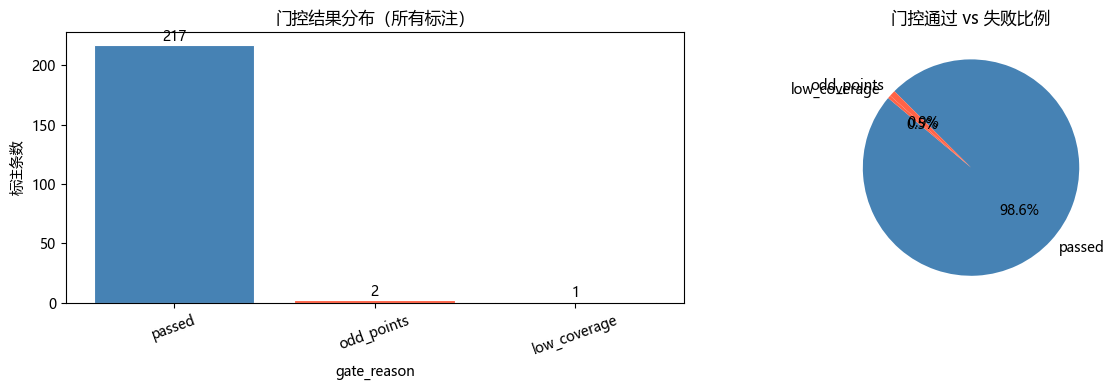


=== 按标注员（user_id）门控通过率 ===
         total  passed  gate_failed  pass_rate
user_id                                       
1          155     155            0   1.000000
2           29      28            1   0.965517
3           23      22            1   0.956522
4           13      12            1   0.923077

=== 门控失败标注详情（共 3 条，显示前20条）===


,task_id,ann_id,user_id,gate_reason,ann_n_pts,pred_n_pts,scope
0,476,31,2,odd_points,15,16,oos_split_level
1,479,79,4,low_coverage,8,8,normal
2,495,50,3,odd_points,11,12,oos_split_level



=== 通过门控标注（N=217）指标汇总 ===
          iou2d     iou3d  depth_rmse    delta1
count  217.0000  217.0000    217.0000  217.0000
mean     0.9707    0.9667      0.0431    0.9730
std      0.1188    0.1252      0.1456    0.1177
min      0.1753    0.1598      0.0000    0.1830
25%      1.0000    1.0000      0.0000    1.0000
50%      1.0000    1.0000      0.0000    1.0000
75%      1.0000    1.0000      0.0000    1.0000
max      1.0000    1.0000      0.8973    1.0000


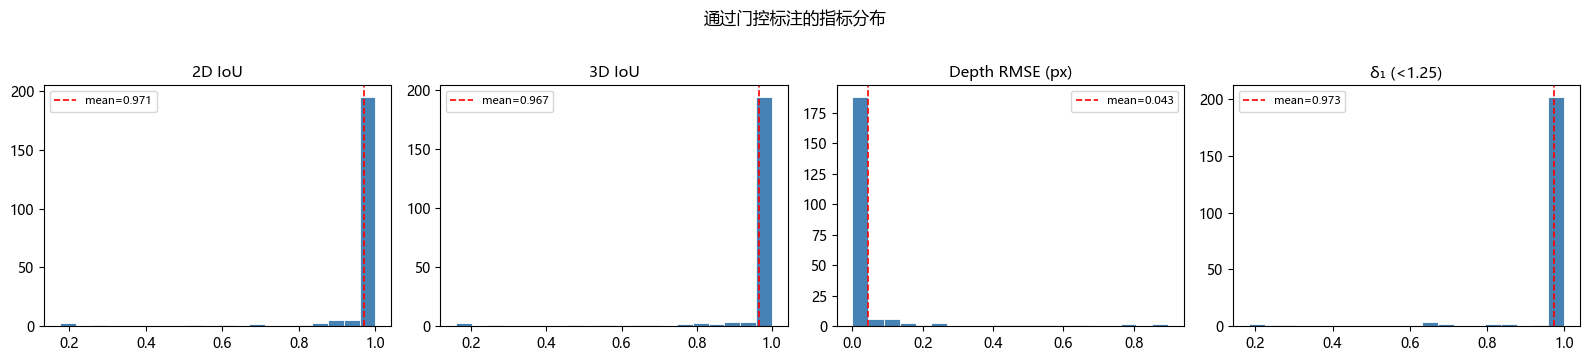

In [2]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = ["Microsoft YaHei", "DejaVu Sans"]

# ── 1. 门控失败类型分布 ────────────────────────────────────────────────────────
gate_counts = df_pilot["gate_reason"].replace("", "passed").value_counts()
print("=== 门控结果分布 ===")
print(gate_counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 左：柱状图
colors = ["steelblue" if g == "passed" else "tomato" for g in gate_counts.index]
axes[0].bar(gate_counts.index, gate_counts.values, color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("门控结果分布（所有标注）", fontsize=12)
axes[0].set_xlabel("gate_reason")
axes[0].set_ylabel("标注条数")
for i, v in enumerate(gate_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha="center", va="bottom", fontsize=10)
axes[0].tick_params(axis="x", rotation=20)

# 右：饼图
wedge_colors = ["steelblue" if g == "passed" else "tomato" for g in gate_counts.index]
axes[1].pie(gate_counts.values, labels=gate_counts.index, autopct="%1.1f%%",
            colors=wedge_colors, startangle=140)
axes[1].set_title("门控通过 vs 失败比例", fontsize=12)

plt.tight_layout()
plt.show()

# ── 2. 按标注员汇总通过率 ──────────────────────────────────────────────────────
print("\n=== 按标注员（user_id）门控通过率 ===")
user_summary = (
    df_pilot.groupby("user_id")
    .agg(
        total=("passed", "count"),
        passed=("passed", "sum"),
        gate_failed=("passed", lambda x: (~x).sum()),
    )
    .assign(pass_rate=lambda d: d["passed"] / d["total"])
    .sort_values("total", ascending=False)
)
print(user_summary.to_string())

# ── 3. 失败标注详情（前20条）──────────────────────────────────────────────────
failed = df_pilot[~df_pilot["passed"]].copy()
print(f"\n=== 门控失败标注详情（共 {len(failed)} 条，显示前20条）===")
cols = ["task_id", "ann_id", "user_id", "gate_reason", "ann_n_pts", "pred_n_pts", "scope"]
try:
    from IPython.display import display
    display(failed[cols].head(20).reset_index(drop=True))
except Exception:
    print(failed[cols].head(20).to_string())

# ── 4. 通过标注的指标分布 ──────────────────────────────────────────────────────
passed_df = df_pilot[df_pilot["passed"]].copy()
if len(passed_df) > 0:
    print(f"\n=== 通过门控标注（N={len(passed_df)}）指标汇总 ===")
    print(passed_df[["iou2d", "iou3d", "depth_rmse", "delta1"]].describe().round(4).to_string())

    fig2, axes2 = plt.subplots(1, 4, figsize=(16, 3.5))
    metrics = [("iou2d", "2D IoU"), ("iou3d", "3D IoU"),
               ("depth_rmse", "Depth RMSE (px)"), ("delta1", "δ₁ (<1.25)")]
    for ax, (col, label) in zip(axes2, metrics):
        vals = passed_df[col].dropna()
        ax.hist(vals, bins=20, color="steelblue", edgecolor="white", linewidth=0.6)
        ax.axvline(vals.mean(), color="red", linestyle="--", linewidth=1.2, label=f"mean={vals.mean():.3f}")
        ax.set_title(label, fontsize=11)
        ax.legend(fontsize=8)
    plt.suptitle("通过门控标注的指标分布", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("没有通过门控的标注，跳过指标分布图。")